In [15]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet34
import numpy as np
import os
import json
from torch.utils.data import DataLoader
from tqdm import tqdm
import torch.nn.functional as F
from torchvision.utils import save_image
import matplotlib.pyplot as plt
from torchvision.datasets import ImageFolder

# Task 1

In [2]:
# Load pretrained ResNet-34
model = torchvision.models.resnet34(weights='IMAGENET1K_V1')
model.eval()
model.cuda()

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /home/rh4145/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 218MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [3]:
# Preprocessing transforms
mean_norms = np.array([0.485, 0.456, 0.406])
std_norms = np.array([0.229, 0.224, 0.225])
plain_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_norms.tolist(), std=std_norms.tolist())
])

In [4]:
# Load test dataset
dataset_path = "./TestDataSet"
test_dataset = torchvision.datasets.ImageFolder(root=dataset_path, transform=plain_transforms)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Load label mapping from .json file
with open("./TestDataSet/labels_list.json", "r") as f:  # Update filename if needed
    idx_to_label = json.load(f)

with open("./TestDataSet/imagenet_class_index.json", "r") as f:
    imagenet_class_index = json.load(f)

# Build synset name → ImageNet index map
synset_to_idx = {v[0]: int(k) for k, v in imagenet_class_index.items()}  # e.g. 'n01440764' → 0

# Get mapping from ImageFolder label index to ImageNet label index
folder_to_imagenet_idx = {
    folder_idx: synset_to_idx[synset]
    for synset, folder_idx in test_dataset.class_to_idx.items()
}

In [5]:
# Evaluation
top1_correct = 0
top5_correct = 0
total = 0

with torch.no_grad():
    for images, labels in tqdm(test_loader):
        images = images.cuda()
        outputs = model(images)
        _, top5_preds = outputs.topk(5, dim=1)

        # Convert folder index to real ImageNet label index
        true_labels = torch.tensor([folder_to_imagenet_idx[label.item()] for label in labels]).cuda()

        # Top-1 accuracy
        top1_correct += (top5_preds[:, 0] == true_labels).sum().item()

        # Top-5 accuracy
        for i in range(len(true_labels)):
            if true_labels[i] in top5_preds[i]:
                top5_correct += 1

        total += len(true_labels)

100%|██████████| 16/16 [00:04<00:00,  3.40it/s]


In [6]:
# Report results
top1_acc = 100 * top1_correct / total
top5_acc = 100 * top5_correct / total
print(f"Top-1 Accuracy: {top1_acc:.2f}%")
print(f"Top-5 Accuracy: {top5_acc:.2f}%")

Top-1 Accuracy: 76.00%
Top-5 Accuracy: 94.20%


# Task 2

In [2]:
# Load model
model = torchvision.models.resnet34(weights='IMAGENET1K_V1').cuda().eval()

# Normalization constants
mean = torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1).cuda()
std = torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1).cuda()

In [3]:
# Inverse normalization for visualization/saving
def denormalize(t):
    return t * std + mean

# FGSM attack
def fgsm_attack(image, label, model, epsilon):
    image.requires_grad = True
    output = model(image)
    loss = F.cross_entropy(output, label)
    model.zero_grad()
    loss.backward()
    perturbation = epsilon * image.grad.data.sign()
    adv_image = image + perturbation
    return torch.clamp(adv_image, (0 - mean) / std, (1 - mean) / std)

In [4]:
def visualize_attack(orig_img, adv_img, pred_probs, pred_labels, class_index_dict, index, save_dir="AdversarialTestSet1/vis"):
    os.makedirs(save_dir, exist_ok=True)

    # Denormalize images
    orig = denormalize(orig_img).squeeze().detach().cpu().clamp(0,1)
    adv = denormalize(adv_img).squeeze().detach().cpu().clamp(0,1)
    orig = denormalize(orig_img).squeeze().detach().cpu().clamp(0,1)
    adv = denormalize(adv_img).squeeze().detach().cpu().clamp(0,1)
    noise = (adv - orig).abs()
    noise = noise / noise.max()  # normalize noise to 0-1 for visibility

    # Convert label indices to class names
    label_names = [class_index_dict[str(i)][1] for i in pred_labels]

    # Plot
    fig, axs = plt.subplots(1, 4, figsize=(12, 3))

    axs[0].imshow(np.transpose(orig.numpy(), (1, 2, 0)))
    axs[0].set_title("Original")
    axs[0].axis('off')

    axs[1].imshow(np.transpose(adv.numpy(), (1, 2, 0)))
    axs[1].set_title("Adversarial")
    axs[1].axis('off')

    axs[2].imshow(noise.permute(1, 2, 0).numpy(), cmap='seismic')
    axs[2].set_title("Noise")
    axs[2].axis('off')

    axs[3].barh(label_names[::-1], pred_probs[::-1])
    axs[3].set_title("Predictions")
    axs[3].set_xlim([0, 1])
    axs[3].set_xlabel("Confidence")

    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f"vis_{index:04d}.png"))
    plt.show()

In [5]:
# Dataset and loader
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

# Load dataset from ImageFolder with synset subfolders
dataset_path = "./TestDataSet"
dataset = torchvision.datasets.ImageFolder(root=dataset_path, transform=transform)
dataloader = DataLoader(dataset, batch_size=1, shuffle=False)

# Load imagenet_class_index.json
with open("./TestDataSet/imagenet_class_index.json", "r") as f:
    class_index_dict = json.load(f)
# synset to official ImageNet index mapping
synset_to_imagenet = {v[0]: int(k) for k, v in class_index_dict.items()}

# Map ImageFolder index → ImageNet index
folder_to_imagenet_idx = {
    folder_idx: synset_to_imagenet[synset]
    for synset, folder_idx in dataset.class_to_idx.items()
}

# Prepare output directory
os.makedirs("AdversarialTestSet1", exist_ok=True)

  0%|          | 1/500 [00:01<11:54,  1.43s/it]

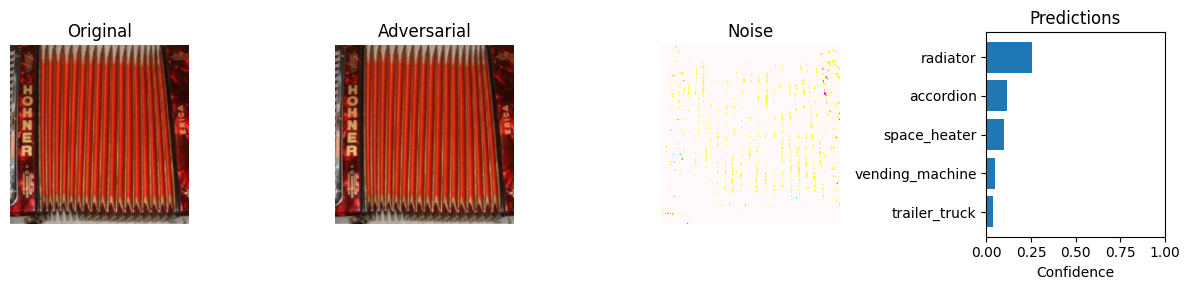

  0%|          | 2/500 [00:01<07:10,  1.16it/s]

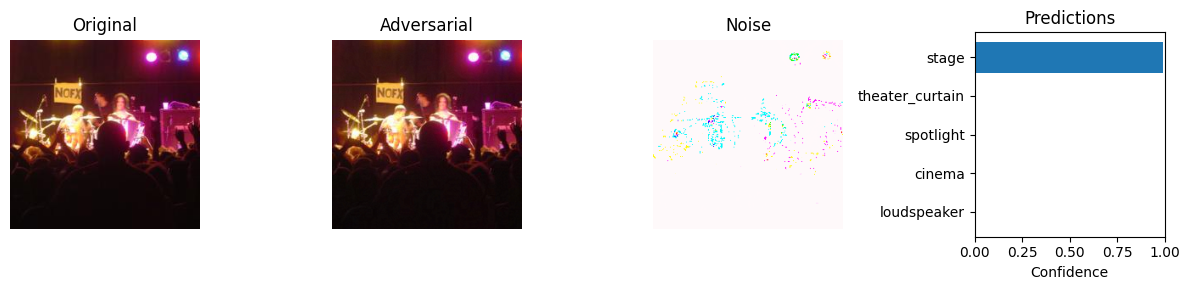

  1%|          | 3/500 [00:02<05:36,  1.48it/s]

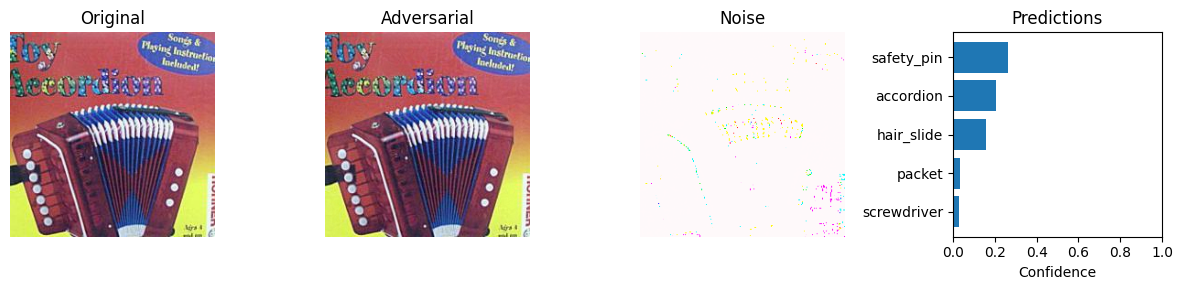

  1%|          | 4/500 [00:02<05:21,  1.54it/s]

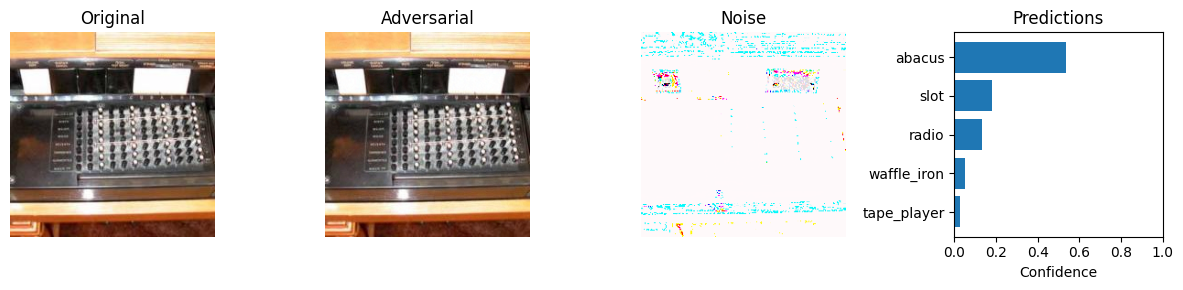

100%|██████████| 500/500 [00:21<00:00, 22.84it/s]


In [11]:
# Accuracy tracking
top1_correct, top5_correct, total = 0, 0, 0

for i, (image, folder_label) in enumerate(tqdm(dataloader)):
    image = image.cuda()
    true_imagenet_label = torch.tensor([folder_to_imagenet_idx[folder_label.item()]]).cuda()

    # FGSM attack
    adv_image = fgsm_attack(image, true_imagenet_label, model, epsilon=0.02)

    # Evaluate
    with torch.no_grad():
        outputs = model(adv_image)
        _, top5_preds = outputs.topk(5, dim=1)
        top1_correct += (top5_preds[:, 0] == true_imagenet_label).sum().item()
        top5_correct += sum([true_imagenet_label[0] in top5_preds[i] for i in range(top5_preds.size(0))])
        total += 1

    # Save adversarial image
    save_image(denormalize(adv_image), f"AdversarialTestSet1/{i:04d}.png")

    # Visualize a few failures
    if i < 5 and top5_preds[:,0] != true_imagenet_label:
        probs = torch.nn.functional.softmax(outputs, dim=1)
        top5_confidences = probs[0, top5_preds[0]].cpu().numpy()
        top5_indices = top5_preds[0].cpu().numpy()
    
        visualize_attack(
            orig_img=image.clone(),
            adv_img=adv_image.clone(),
            pred_probs=top5_confidences,
            pred_labels=top5_indices,
            class_index_dict=class_index_dict,
            index=i
        )

In [12]:
# Print results
top1_acc = 100 * top1_correct / total
top5_acc = 100 * top5_correct / total
print(f"\nFGSM Adversarial Accuracy:")
print(f"Top-1: {top1_acc:.2f}%")
print(f"Top-5: {top5_acc:.2f}%")


FGSM Adversarial Accuracy:
Top-1: 6.20%
Top-5: 35.40%


# Task 3

In [13]:
def pgd_attack(image, label, model, epsilon=0.02, alpha=0.005, steps=10):
    orig = image.detach()
    perturbed = image.clone().detach().requires_grad_(True)

    for _ in range(steps):
        output = model(perturbed)
        loss = F.cross_entropy(output, label)
        model.zero_grad()
        loss.backward()

        with torch.no_grad():
            perturbation = alpha * perturbed.grad.sign()
            perturbed = perturbed + perturbation
            perturbed = torch.max(torch.min(perturbed, orig + epsilon), orig - epsilon)
            perturbed = perturbed.detach().requires_grad_(True)

    return perturbed

  0%|          | 0/500 [00:00<?, ?it/s]

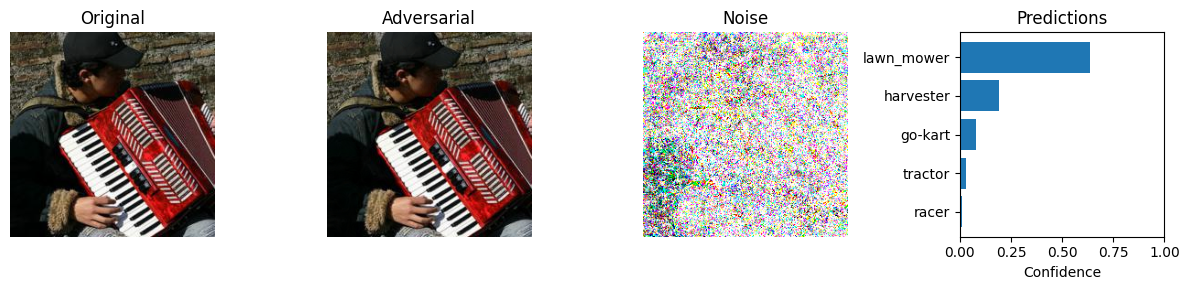

  0%|          | 1/500 [00:00<06:07,  1.36it/s]

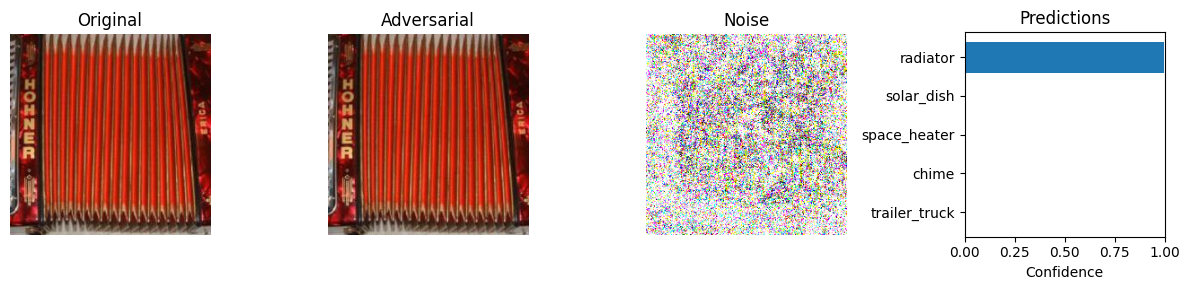

  0%|          | 2/500 [00:01<05:17,  1.57it/s]

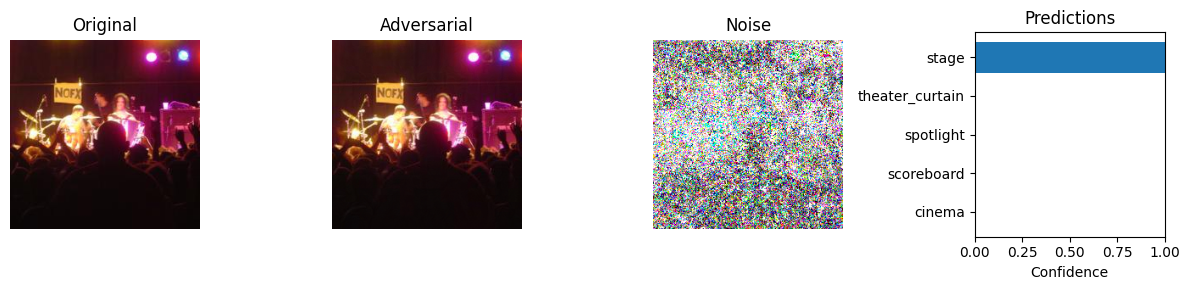

  1%|          | 3/500 [00:01<04:56,  1.68it/s]

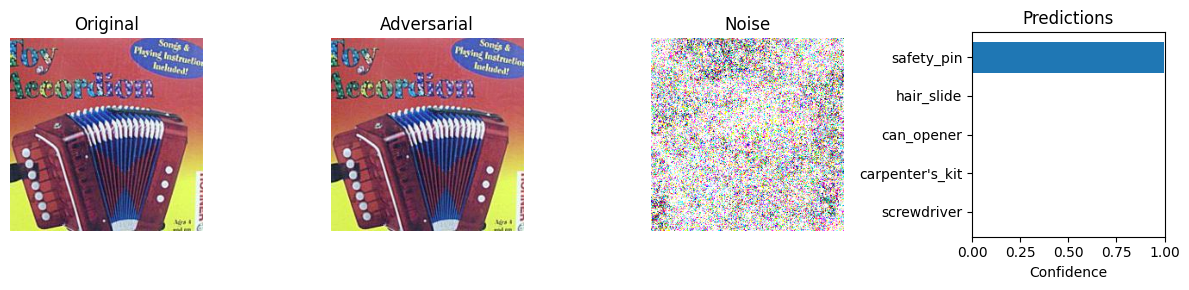

  1%|          | 4/500 [00:02<04:43,  1.75it/s]

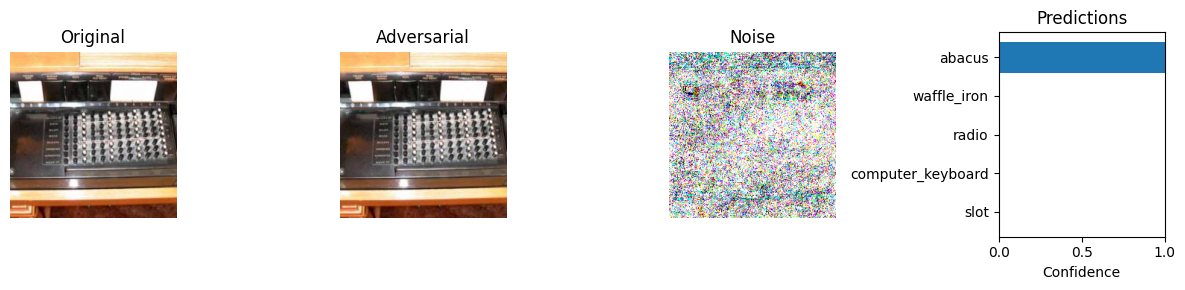

100%|██████████| 500/500 [01:06<00:00,  7.48it/s]


PGD Attack Accuracy:
Top-1: 0.00%
Top-5: 9.60%


In [14]:
# Accuracy tracking
top1_correct, top5_correct, total = 0, 0, 0
save_dir = "AdversarialTestSet2"
os.makedirs(save_dir, exist_ok=True)

for i, (image, folder_label) in enumerate(tqdm(dataloader)):
    image = image.cuda()
    true_imagenet_label = torch.tensor([folder_to_imagenet_idx[folder_label.item()]]).cuda()

    # PGD attack
    adv_image = pgd_attack(image, true_imagenet_label, model, epsilon=0.02, alpha=0.005, steps=10)

    # Evaluate
    with torch.no_grad():
        outputs = model(adv_image)
        _, top5_preds = outputs.topk(5, dim=1)
        top1_correct += (top5_preds[:, 0] == true_imagenet_label).sum().item()
        top5_correct += sum([true_imagenet_label[0] in top5_preds[i] for i in range(top5_preds.size(0))])
        total += 1

    # Save image
    save_image(denormalize(adv_image), f"{save_dir}/{i:04d}.png")

    # Visualize a few
    if i < 5 and top5_preds[:,0] != true_imagenet_label:
        probs = torch.nn.functional.softmax(outputs, dim=1)
        top5_confidences = probs[0, top5_preds[0]].cpu().numpy()
        top5_indices = top5_preds[0].cpu().numpy()

        visualize_attack(
            orig_img=image.clone(),
            adv_img=adv_image.clone(),
            pred_probs=top5_confidences,
            pred_labels=top5_indices,
            class_index_dict=class_index_dict,
            index=i,
            save_dir=os.path.join(save_dir, "vis")
        )

# Report accuracy
print(f"\nPGD Attack Accuracy:")
print(f"Top-1: {100 * top1_correct / total:.2f}%")
print(f"Top-5: {100 * top5_correct / total:.2f}%")

# Task 4

In [6]:
def generate_random_patch_mask(image, patch_size=32):
    B, C, H, W = image.shape
    mask = torch.zeros_like(image)

    for b in range(B):
        x = torch.randint(0, H - patch_size + 1, (1,))
        y = torch.randint(0, W - patch_size + 1, (1,))
        mask[b, :, x:x+patch_size, y:y+patch_size] = 1.0

    return mask

def pgd_patch_attack(image, label, model, epsilon=0.5, alpha=0.05, steps=10, patch_size=32):
    orig = image.detach()
    perturbed = image.clone().detach().requires_grad_(True)

    # Create a fixed mask for this image
    mask = generate_random_patch_mask(image, patch_size=patch_size)

    for _ in range(steps):
        output = model(perturbed)
        loss = F.cross_entropy(output, label)
        model.zero_grad()
        loss.backward()

        with torch.no_grad():
            grad = perturbed.grad.sign()
            perturbation = alpha * grad * mask
            perturbed = perturbed + perturbation
            perturbed = torch.max(torch.min(perturbed, orig + epsilon * mask), orig - epsilon * mask)
            perturbed = perturbed.detach().requires_grad_(True)

    return perturbed

  0%|          | 2/500 [00:00<01:29,  5.54it/s]

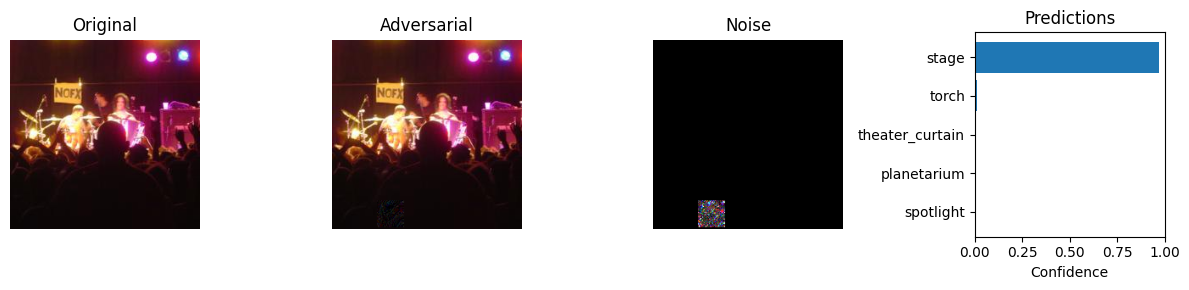

  1%|          | 4/500 [00:01<02:06,  3.91it/s]

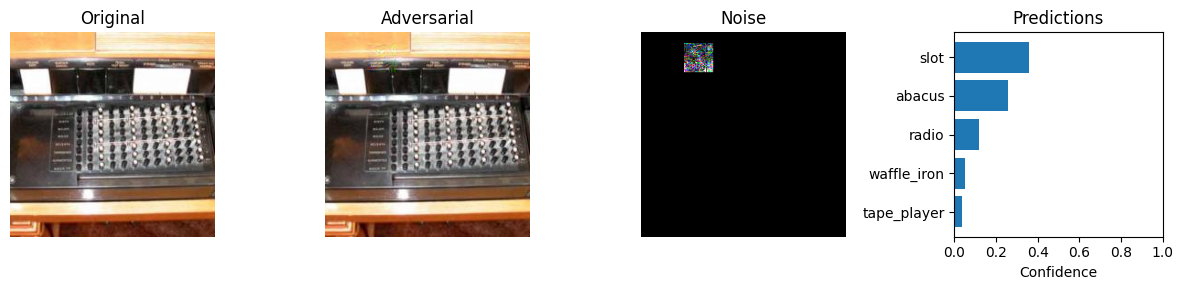

100%|██████████| 500/500 [01:30<00:00,  5.50it/s]


In [10]:
save_dir = "AdversarialTestSet3"
os.makedirs(save_dir, exist_ok=True)
top1_correct, top5_correct, total = 0, 0, 0

for i, (image, folder_label) in enumerate(tqdm(dataloader)):
    image = image.cuda()
    true_label = torch.tensor([folder_to_imagenet_idx[folder_label.item()]]).cuda()

    adv_image = pgd_patch_attack(
        image=image,
        label=true_label,
        model=model,
        epsilon=0.5,
        alpha=0.05,
        steps=20,
        patch_size=32
    )

    # Evaluate
    with torch.no_grad():
        output = model(adv_image)
        _, top5_preds = output.topk(5, dim=1)
        top1_correct += (top5_preds[:, 0] == true_label).sum().item()
        top5_correct += sum([true_label[0] in top5_preds[i] for i in range(top5_preds.size(0))])
        total += 1

    # Save adversarial image
    save_image(denormalize(adv_image), f"{save_dir}/{i:04d}.png")

    # Optional: Visualize
    if i < 5 and top5_preds[:, 0] != true_label:
        probs = torch.nn.functional.softmax(output, dim=1)
        top5_conf = probs[0, top5_preds[0]].cpu().numpy()
        top5_idx = top5_preds[0].cpu().numpy()

        visualize_attack(
            orig_img=image.clone(),
            adv_img=adv_image.clone(),
            pred_probs=top5_conf,
            pred_labels=top5_idx,
            class_index_dict=class_index_dict,
            index=i,
            save_dir=os.path.join(save_dir, "vis")
        )

In [11]:
# Report
print(f"\nPatch Attack Accuracy:")
print(f"Top-1: {100 * top1_correct / total:.2f}%")
print(f"Top-5: {100 * top5_correct / total:.2f}%")


Patch Attack Accuracy:
Top-1: 31.00%
Top-5: 73.00%


# Task 5

In [12]:
# Load new model (e.g., DenseNet-121)
new_model = torchvision.models.densenet121(weights='IMAGENET1K_V1').cuda().eval()

# Normalization
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /home/rh4145/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 270MB/s]


In [21]:
# Paths to all datasets
dataset_names = ["Original", "FGSM", "PGD", "Patch"]
dataset_paths = [
    "./TestDataSet",
    "./AdversarialTestSet1",
    "./AdversarialTestSet2",
    "./AdversarialTestSet3"
]

In [22]:
# Evaluate function
def evaluate_model_on_dataset(model, dataset_path, class_map):
    dataset = ImageFolder(dataset_path, transform=test_transform)
    loader = DataLoader(dataset, batch_size=32, shuffle=False)

    top1, top5, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in tqdm(loader):
            images = images.cuda()
            labels = torch.tensor([class_map[l.item()] for l in labels]).cuda()

            outputs = model(images)
            _, top5_preds = outputs.topk(5, dim=1)
            top1 += (top5_preds[:, 0] == labels).sum().item()
            top5 += sum([labels[i] in top5_preds[i] for i in range(len(labels))])
            total += labels.size(0)

    top1_acc = 100 * top1 / total
    top5_acc = 100 * top5 / total
    return top1_acc, top5_acc

# Run evaluation
results = []
for name, path in zip(dataset_names, dataset_paths):
    print(f"\nEvaluating on: {name}")
    acc1, acc5 = evaluate_model_on_dataset(new_model, path, folder_to_imagenet_idx)
    results.append((name, acc1, acc5))



Evaluating on: Original


100%|██████████| 16/16 [00:01<00:00, 12.17it/s]



Evaluating on: FGSM


100%|██████████| 1/1 [00:00<00:00, 11.58it/s]



Evaluating on: PGD


100%|██████████| 1/1 [00:00<00:00,  8.54it/s]



Evaluating on: Patch


100%|██████████| 1/1 [00:00<00:00, 22.39it/s]


In [23]:
for name, acc1, acc5 in results:
    print(f"{name:<12} | Top-1 Accuracy: {acc1:.2f}% | Top-5 Accuracy: {acc5:.2f}%")

Original     | Top-1 Accuracy: 74.80% | Top-5 Accuracy: 93.60%
FGSM         | Top-1 Accuracy: 0.00% | Top-5 Accuracy: 25.00%
PGD          | Top-1 Accuracy: 0.00% | Top-5 Accuracy: 40.00%
Patch        | Top-1 Accuracy: 0.00% | Top-5 Accuracy: 0.00%
